<a href="https://colab.research.google.com/github/s4tlaw/KTH_AH2179/blob/main/KTH_AH2179_asm_1_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Data

In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df = pd.read_csv(url)
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [2]:
df.shape

(17379, 17)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [4]:
# df = df.iloc[:1000]
df_2012 = df[df["yr"] == 1]
df = df[df["yr"] == 0]

In [5]:
df.shape

(8645, 17)

In [6]:
df_2012.shape

(8734, 17)

# Feature interaction

Target: cnt (count of total rental bikes including both casual and registered)

Predictors: weather (temp, atemp, hum, windspeed, weathersit), calendar (hr, weekday, workingday, holiday, season), and yr.

In [7]:
df = df.drop(['instant', 'dteday', 'mnth', 'casual', 'registered', 'yr'], axis=1)
df_2012 = df_2012.drop(['instant', 'dteday', 'mnth', 'casual', 'registered', 'yr'], axis=1)

# Data Split

In [8]:

from sklearn.model_selection import train_test_split
target = 'cnt'

X = df.copy()
y = df[target].astype(float)

X.drop(columns=[target], inplace=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Baseline Linear Regression Result

Mean Absolute Error: 79.2362160065101
Mean Squared Error: 11256.611672490775
R-squared: 0.3928566300175752


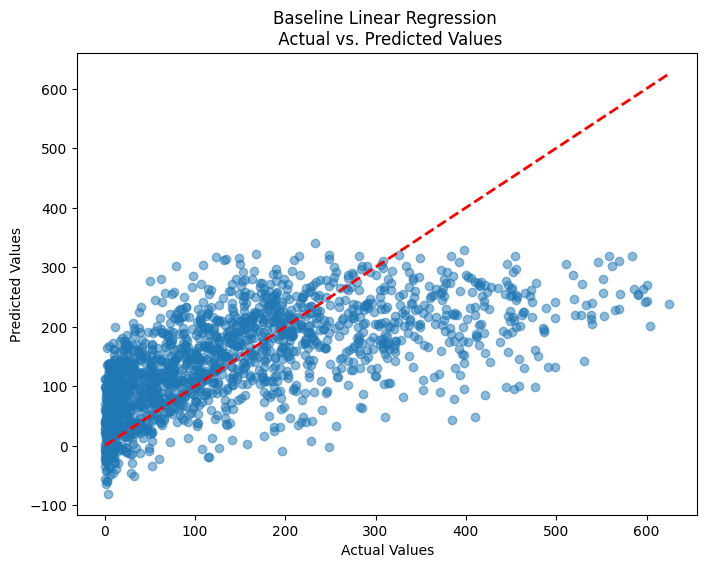

In [9]:
from sklearn.linear_model import LinearRegression

# Create a Linear Regression model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Predict the test data with the fitted model
y_pred = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse_base = mean_squared_error(y_test, y_pred)
r2_base = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse_base}")
print(f"R-squared: {r2_base}")

import matplotlib.pyplot as plt

# y_test contains the actual target values for the test dataset
# y_pred contains the predicted values for the test dataset

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)  # Plot actual vs. predicted values

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Baseline Linear Regression \n Actual vs. Predicted Values")

# Add a diagonal line for reference (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

# Show the plot
plt.show()

# Normalization Result

Mean Absolute Error: 79.2362
Mean Squared Error: 11256.6117
R-squared: 0.3929


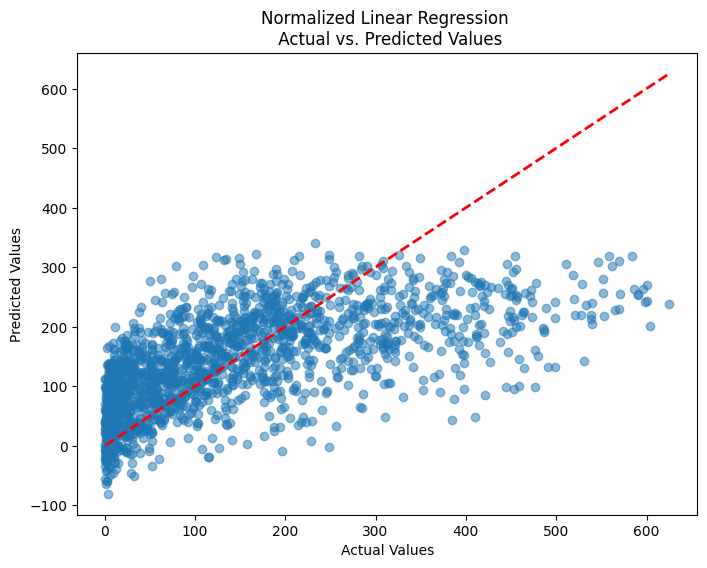

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_norm = LinearRegression()
model_norm.fit(X_train_scaled, y_train)
y_pred_norm = model_norm.predict(X_test_scaled)

mae_norm = mean_absolute_error(y_test, y_pred_norm)
mse_norm = mean_squared_error(y_test, y_pred_norm)
r2_norm = r2_score(y_test, y_pred_norm)

print(f"Mean Absolute Error: {mae_norm:.4f}")
print(f"Mean Squared Error: {mse_norm:.4f}")
print(f"R-squared: {r2_norm:.4f}")

# y_test contains the actual target values for the test dataset
# y_pred contains the predicted values for the test dataset

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_norm, alpha=0.5)  # Plot actual vs. predicted values

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Normalized Linear Regression \n Actual vs. Predicted Values")

# Add a diagonal line for reference (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

# Show the plot
plt.show()

# Normalization + XGBoost & Result

Mean Squared Error: 1141.7752
R² Score: 0.9384


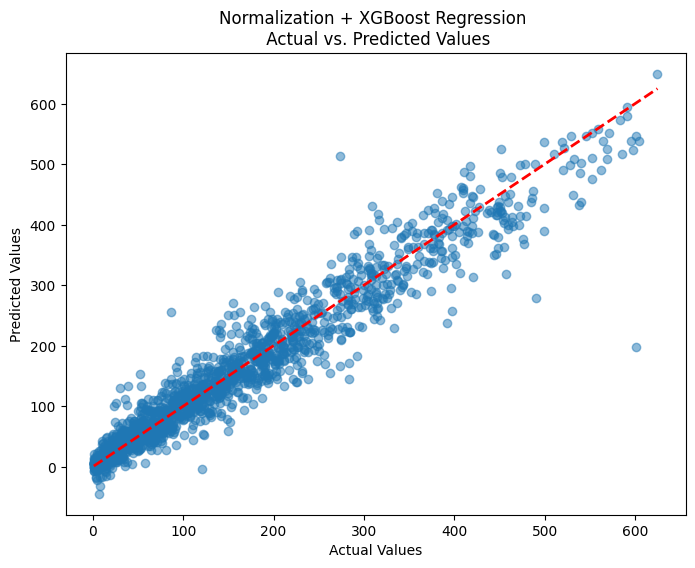

In [11]:
import xgboost as xgb
model_XG = xgb.XGBRegressor()

# 4. Train the model
model_XG.fit(X_train_scaled, y_train)

# 3. Make predictions (will output continuous numerical values)
predictions = model_XG.predict(X_test_scaled)

# 4. Evaluate using regression metrics
mse_before = mean_squared_error(y_test, predictions)
r2_before = r2_score(y_test, predictions)

print(f"Mean Squared Error: {mse_before:.4f}")
print(f"R² Score: {r2_before:.4f}")


# y_test contains the actual target values for the test dataset
# predictions contains the predicted values for the test dataset

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5)  # Plot actual vs. predicted values

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Normalization + XGBoost Regression \n Actual vs. Predicted Values")

# Add a diagonal line for reference (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

# Show the plot
plt.show()

# Normalization + Grid + XGboost

In [12]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

model_XG_Grid = xgb.XGBRegressor()

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=model_XG_Grid,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV RMSE:", (-grid_search.best_score_) ** 0.5)

best_model = grid_search.best_estimator_


Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'subsample': 0.8}
Best CV RMSE: 33.68649433493634


Test RMSE: 985.8669
Test R2: 0.9468


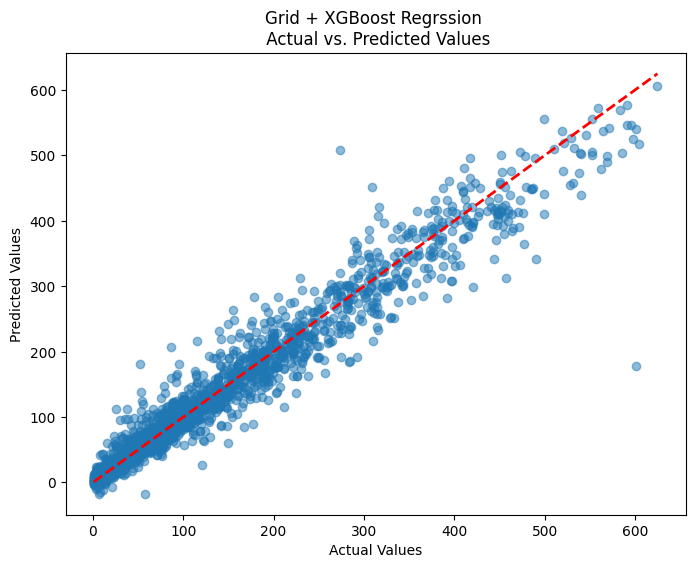

In [13]:
best_model.fit(X_train_scaled, y_train)
preds = best_model.predict(X_test_scaled)
mse_after = mean_squared_error(y_test, preds)
r2_after = r2_score(y_test, preds)

print(f"Test RMSE: {mse_after:.4f}")
print(f"Test R2: {r2_after:.4f}")

# y_test contains the actual target values for the test dataset
# preds contains the predicted values for the test dataset

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
plt.scatter(y_test, preds, alpha=0.5)  # Plot actual vs. predicted values

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Grid + XGBoost Regrssion \n Actual vs. Predicted Values")

# Add a diagonal line for reference (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

# Show the plot
plt.show()

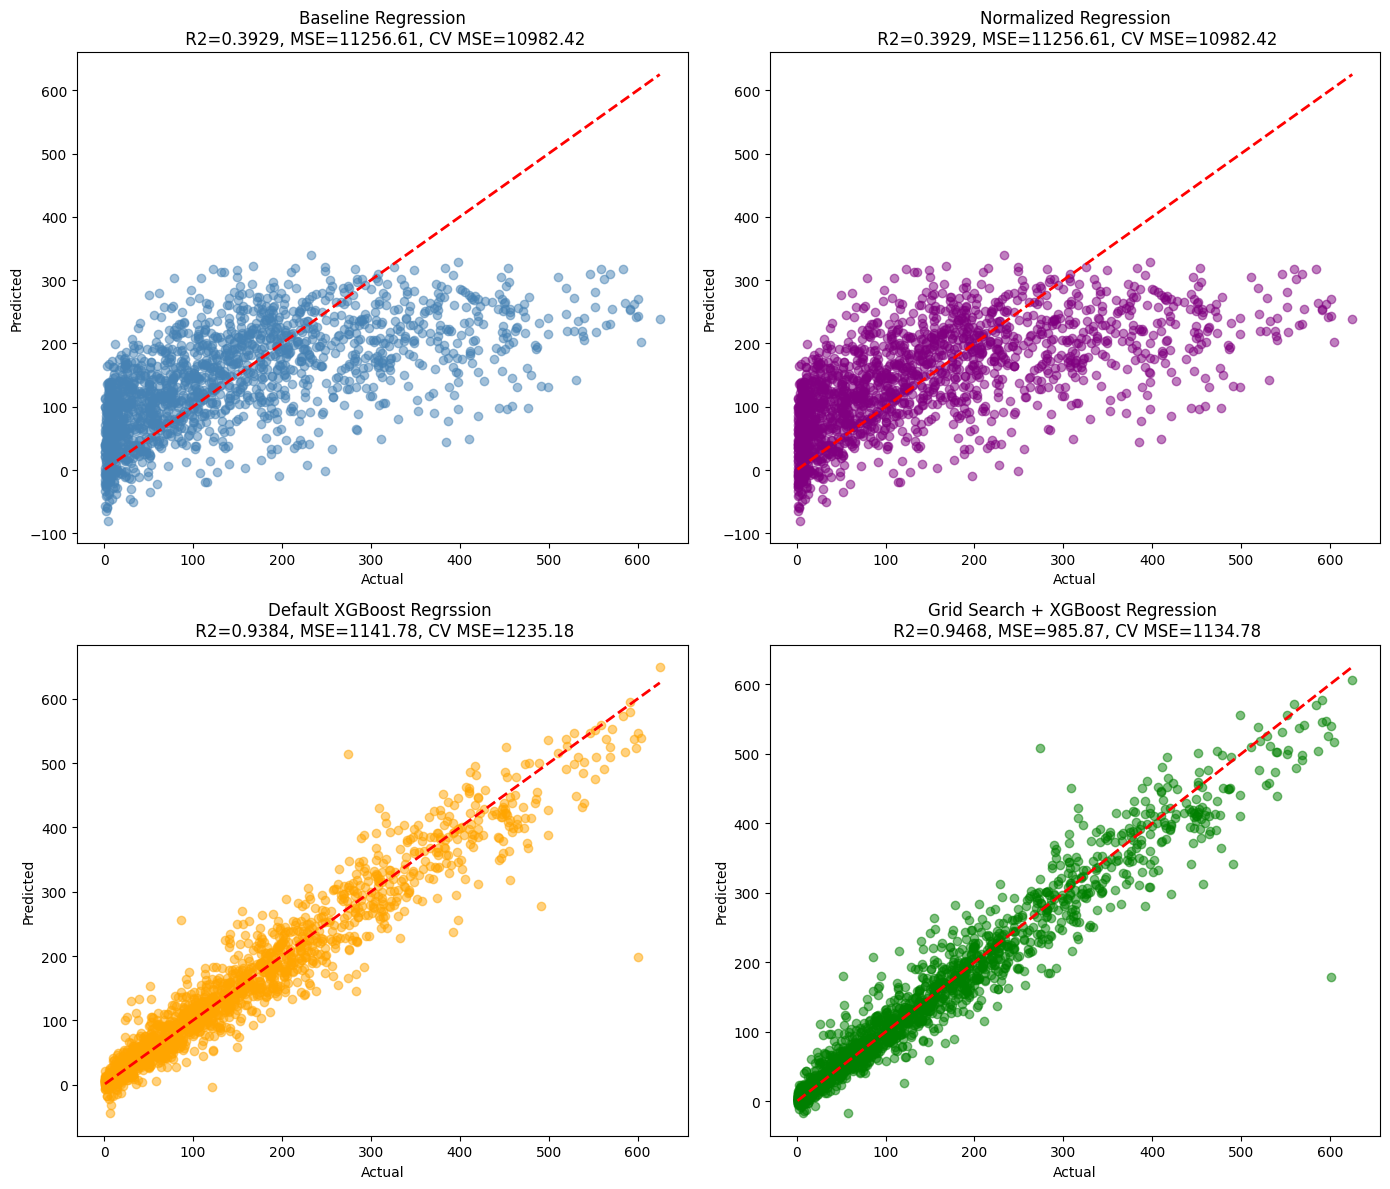

In [14]:
from sklearn.model_selection import cross_val_score

cv_mse_base = -cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error').mean()
cv_mse_norm = -cross_val_score(model_norm, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error').mean()
cv_mse_before = -cross_val_score(model_XG, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error').mean()
cv_mse_after = -cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error').mean()

# results_df = pd.DataFrame({
#     'Model': ['Baseline Linear Regression', 'Normalized Linear Regression', 'Default XGBoost', 'Grid Search XGBoost'],
#     'Test MSE': [mse_base, mse_norm, mse_before, mse_after],
#     'Test R2': [r2_base, r2_norm, r2_before, r2_after],
#     'CV MSE': [cv_mse_base, cv_mse_norm, cv_mse_before, cv_mse_after]
# })
# print(results_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0,0].scatter(y_test, y_pred, alpha=0.5, color='steelblue')
axes[0,0].plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--', color='red', lw=2)
axes[0,0].set_title(f"Baseline Regression\n R2={r2_base:.4f}, MSE={mse_base:.2f}, CV MSE={cv_mse_base:.2f}")
axes[0,0].set_xlabel("Actual"); axes[0,0].set_ylabel("Predicted")

axes[0,1].scatter(y_test, y_pred_norm, alpha=0.5, color='purple')
axes[0,1].plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--', color='red', lw=2)
axes[0,1].set_title(f"Normalized Regression\n R2={r2_norm:.4f}, MSE={mse_norm:.2f}, CV MSE={cv_mse_norm:.2f}")
axes[0,1].set_xlabel("Actual"); axes[0,1].set_ylabel("Predicted")

axes[1,0].scatter(y_test, predictions, alpha=0.5, color='orange')
axes[1,0].plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--', color='red', lw=2)
axes[1,0].set_title(f"Default XGBoost Regrssion \n R2={r2_before:.4f}, MSE={mse_before:.2f}, CV MSE={cv_mse_before:.2f}")
axes[1,0].set_xlabel("Actual"); axes[1,0].set_ylabel("Predicted")

axes[1,1].scatter(y_test, preds, alpha=0.5, color='green')
axes[1,1].plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--', color='red', lw=2)
axes[1,1].set_title(f"Grid Search + XGBoost Regression \n R2={r2_after:.4f}, MSE={mse_after:.2f}, CV MSE={cv_mse_after:.2f}")
axes[1,1].set_xlabel("Actual"); axes[1,1].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

# Prediction testing 2011 model Vs 2012 raw data

2012 Test MSE: 15302.1765
2012 Test R2: 0.6493


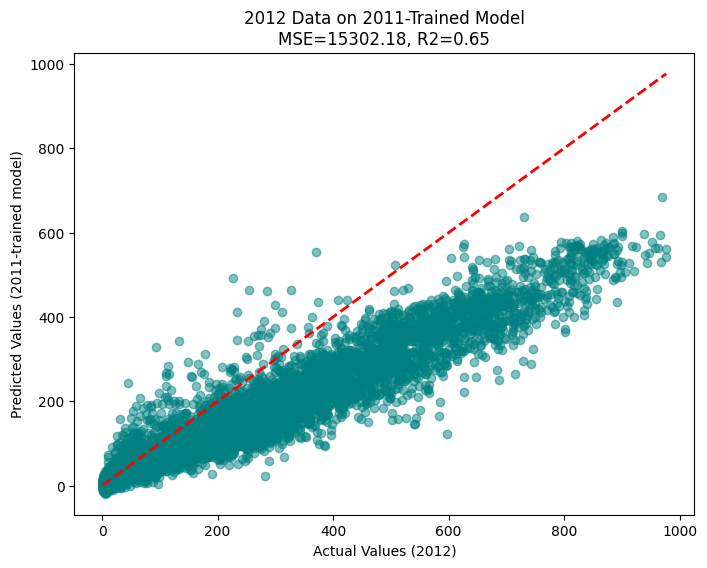

In [20]:
target = 'cnt'

X_2012 = df_2012.drop(columns=[target])
y_2012 = df_2012[target].astype(float)

X_2012_scaled = scaler.transform(X_2012)

preds_2012 = best_model.predict(X_2012_scaled)

mse_2012 = mean_squared_error(y_2012, preds_2012)
r2_2012 = r2_score(y_2012, preds_2012)

print(f"2012 Test MSE: {mse_2012:.4f}")
print(f"2012 Test R2: {r2_2012:.4f}")


plt.figure(figsize=(8, 6))
plt.scatter(y_2012, preds_2012, alpha=0.5, color='teal')
plt.plot([min(y_2012), max(y_2012)], [min(y_2012), max(y_2012)], linestyle='--', color='red', lw=2)
plt.xlabel("Actual Values (2012)")
plt.ylabel("Predicted Values (2011-trained model)")
plt.title(f"2012 Data on 2011-Trained Model\nMSE={mse_2012:.2f}, R2={r2_2012:.2f}")
plt.show()

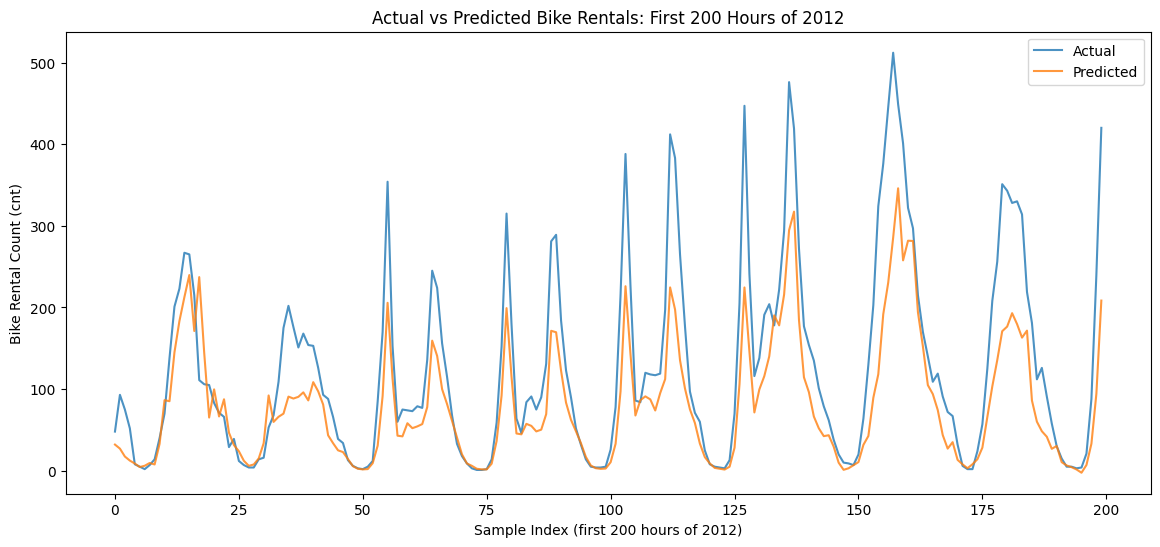

In [21]:
plt.figure(figsize=(14, 6))
plt.plot(y_2012.values[:200], label='Actual', alpha=0.8)
plt.plot(preds_2012[:200], label='Predicted', alpha=0.8)
plt.xlabel("Sample Index (first 200 hours of 2012)")
plt.ylabel("Bike Rental Count (cnt)")
plt.title("Actual vs Predicted Bike Rentals: First 200 Hours of 2012")
plt.legend()
plt.show()

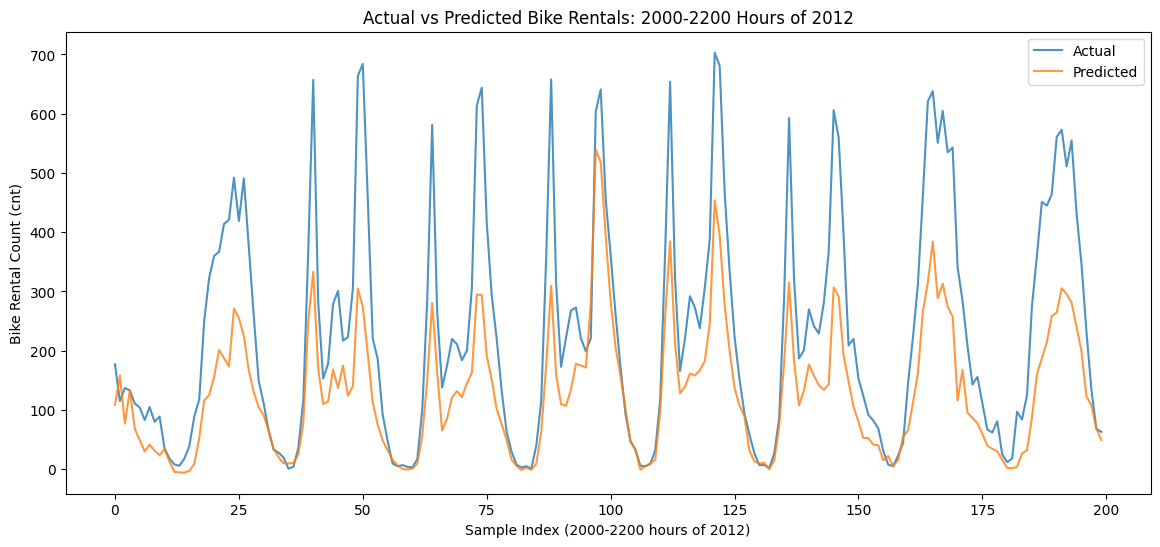

In [24]:
plt.figure(figsize=(14, 6))
plt.plot(y_2012.values[2000:2200], label='Actual', alpha=0.8)
plt.plot(preds_2012[2000:2200], label='Predicted', alpha=0.8)
plt.xlabel("Sample Index (2000-2200 hours of 2012)")
plt.ylabel("Bike Rental Count (cnt)")
plt.title("Actual vs Predicted Bike Rentals: 2000-2200 Hours of 2012")
plt.legend()
plt.show()

# Report

## 1. Data
Study the meaning of the raw data from [database](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset).


## 2. Data Pre-process

**Filter: Feature interaction**

- Target (Output Variable): 'cnt'

- Features (Input Variable): 'temp, atemp, hum, windspeed, weathersit, hr, weekday, workingday, holiday, season'

**Split Train/Test**

**Nomalization**

## 3. Model evaluation Metrics

- $R^2$ value
- MSE
- CV MSE
- Visual Chart

## 4. Model Enhancement Technic

We set a baseline of using linear regression on raw data. And we further enhance the model by using XGBoost Regression & Grid Search.

The effect of using these techniques is significant with the evaluation metrics.
- $R^2$ > 0.9 in testing data
- $R^2$ > 0.6 in 2012 data

## 5. Reflection

The whole practice indicated the imporatantce to organize data and use the right technic to enhance the model.

### Second try

After the first try with two years data for modeling, I found that there is no practical way to verify the model. So I decided to sperate 2011 and 2012 data. by using 2011 data for training the model and using 2012 data for verification.

Additional learnt information
- What does normalization do and why it dont affect the regession?
- What is MSE and CV MSE?
